<a href="https://colab.research.google.com/github/grownsandip/ML_Algo/blob/main/house_price_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**This program is to see the linear regression implementation of house price prediction based on price and area of house**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


*loading data from drive to colab environment*

In [10]:
import pandas as pd
path ="/content/drive/MyDrive/house/kc_house_data.csv"
data = pd.read_csv(path)
data.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [14]:
data.shape # there are 21613 instances and 21 parameters

(21613, 21)

**We are going to check if our dataset has missing values**

In [15]:
data.isnull().sum() #the output suggests there are no missing values

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


## We will take living_area and price features and create a new dataset from prevoius one for model training

In [16]:
new_data=pd.DataFrame(data.price) #taking the price feature
new_data['area']=data.sqft_living

In [17]:
new_data.shape

(21613, 2)

In [18]:
new_data.head()

,price,area
0,221900.0,1180
1,538000.0,2570
2,180000.0,770
3,604000.0,1960
4,510000.0,1680


**Now we shall explore data to see missing values and probable outliers that might effect the model training**

In [19]:
new_data.isnull().sum() #out put suggests no missing values

,0
price,0
area,0


**lets visualize data on a scatter plot**

In [20]:
import matplotlib.pyplot as plt #import matplotlib
import plotly.express as px #import pyplot express
fig = px.scatter(x = new_data.price, y = new_data.area, labels = {'x' : 'price', 'y' : 'area'}, trendline="ols")
fig.data[1].line.color = 'red'
fig.show()

conclusion is one outlier is present and it has area greater than 13000sqft so will drop it

In [21]:
new_data.loc[(new_data.area>13000)]

,price,area
12777,2280000.0,13540


In [23]:
new_data.drop(new_data.query("area > 13000").index, inplace=True) #dropping the outlier

In [24]:
new_data.shape

(21612, 2)

In [25]:
fig = px.scatter(x = new_data.price, y = new_data.area, labels = {'x' : 'price', 'y' : 'area'}, trendline="ols")
fig.data[1].line.color = 'red'
fig.show()

**Splitting the dataset into training and testing set**

In [26]:
feature=new_data.area.values
target=new_data.price.values
print("feature:",feature)
print("target:",target)

feature: [1180 2570  770 ... 1020 1600 1020]
target: [221900. 538000. 180000. ... 402101. 400000. 325000.]


In [27]:
feature=feature.reshape(-1,1)   #converting into two dimensional arrays
target=target.reshape(-1,1)
print("feature:",feature)
print("target:",target)


feature: [[1180]
 [2570]
 [ 770]
 ...
 [1020]
 [1600]
 [1020]]
target: [[221900.]
 [538000.]
 [180000.]
 ...
 [402101.]
 [400000.]
 [325000.]]


splitting to training and testing 20% for testing and remaining 80% for trainig model

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(feature, target, test_size = 0.2, random_state = 0)
print("X-Train :",X_train.shape)
print("X-Test :",X_test.shape)
print("Y-Train :",Y_test.shape)
print("Y-Test :",Y_test.shape)

X-Train : (17289, 1)
X-Test : (4323, 1)
Y-Train : (4323, 1)
Y-Test : (4323, 1)


next we train model based on training and testing data

In [30]:
from sklearn.linear_model import LinearRegression
model=LinearRegression() #creating object of class
model.fit(X_train, Y_train) #fitting the model

LinearRegression()

plotting regression line linear vs actual

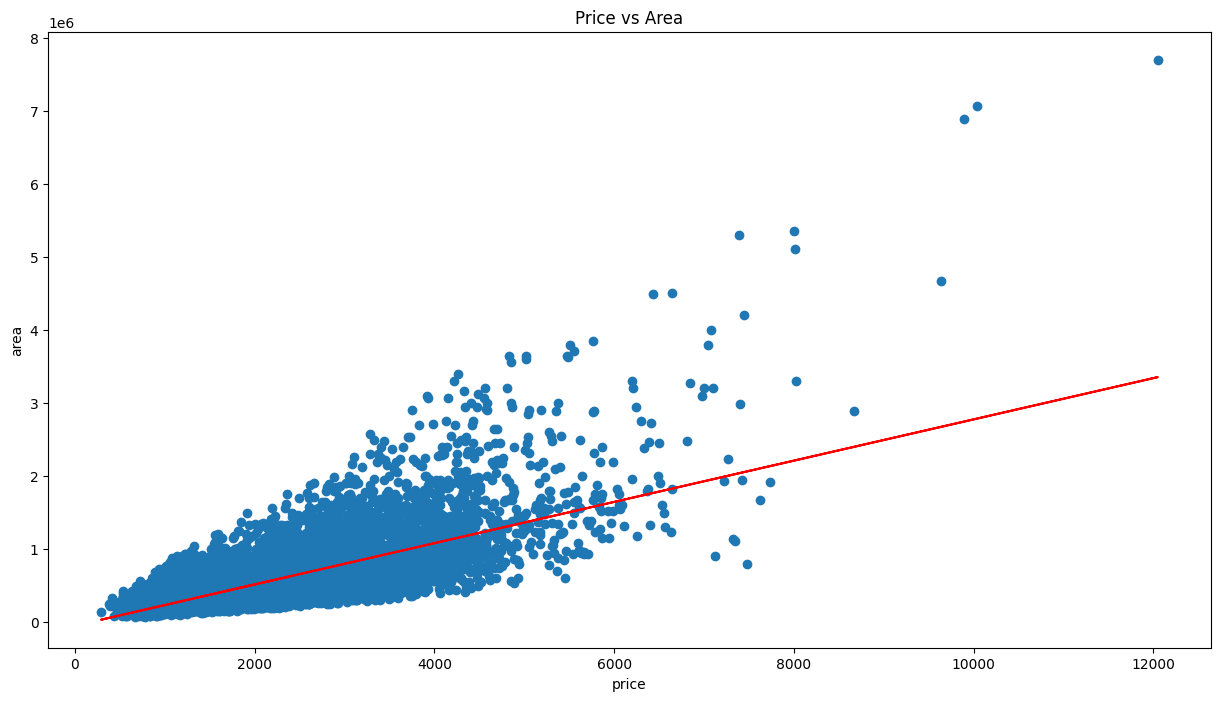

In [31]:
plt.figure(figsize = (15,8))
plt.scatter(X_train, Y_train)
plt.plot(X_train, model.predict(X_train), color = 'red')
plt.title('Price vs Area')
plt.xlabel('price')
plt.ylabel('area')
plt.show()

predicting the values

In [32]:
pred_vals = model.predict(X_test)
pred_vals

array([[1045528.42626356],
       [ 314046.5628408 ],
       [ 921261.23711066],
       ...,
       [ 949503.78009995],
       [ 260385.73116114],
       [ 746157.47057702]])

creating dataframe actual vs predicted

In [33]:
df_ac_vs_pr = pd.DataFrame(pred_vals, index = range(0,4323), columns = ['Predicted'])
df_ac_vs_pr['Actual'] = Y_test

In [34]:
df_ac_vs_pr.head()

,Predicted,Actual
0,1.045528e+06,900000.0
1,3.140466e+05,405000.0
2,9.212612e+05,780000.0
3,6.902372e+05,379950.0
4,7.969940e+05,1061600.0


**Evauating the performance of model**

In [35]:
from sklearn.metrics import mean_absolute_error
print('Mean Absolute Error =', mean_absolute_error(Y_test, pred_vals))

Mean Absolute Error = 173617.22853030873


In [36]:
import numpy as np
# Defining variable 'y' with given data
y = np.array(3000)
y = y.reshape(-1, 1)

# Predicting on the basis of the value in 'y'
pred_y = model.predict(y)
pred_y

array([[799818.30225669]])

In [37]:
print('The score obtained after studying for {} hours = {}'.format(y[0][0], pred_y[0][0]))

The score obtained after studying for 3000 hours = 799818.3022566854


Calculating MAEP(mean absolute error percentage)

In [38]:
def maep(actual,pred):
  actual,pred=np.array(actual),np.array(pred)
  return np.mean(np.abs((actual-pred)/actual))*100

maep(Y_test, pred_vals)

35.8170035842334

Conclusion our model is has 36% mean absloute error percentage which mean price is insufficient as a parameter to predict accurate prices